In [7]:
from random import randint
import time
import matplotlib.pyplot as plt


def random_list_gen(n):
    return [randint(1, 100000) for _ in range(n)]


def almost_sorted_list(n):
    arr = list(range(n))

    swaps = n // 20

    for _ in range(swaps):
        i = randint(0, n - 1)
        j = randint(0, n - 1)
        arr[i], arr[j] = arr[j], arr[i]

    return arr


def bubble_sort(nums):
    n = len(nums)
    i = 0
    while i < n:
        were_swapped = False
        for j in range(n - 1, i, -1):
            if nums[j] < nums[j - 1]:
                # элементы меняются местами, если текущий элемент меньше предыдущего
                nums[j], nums[j - 1] = nums[j - 1], nums[j]
                were_swapped = True
        if not were_swapped:  # данный флаг обеспечивает ранний выход из цикла, что является хорошей оптимизацией
            break
        i += 1
    return nums


def merge(arr, left, mid, right):
    # Размеры левой и правой частей
    left_size = mid - left + 1
    right_size = right - mid

    L = [0] * left_size
    R = [0] * right_size

    # Копирование левой части
    for i in range(left_size):
        L[i] = arr[left + i]

    # Копирование правой части
    for j in range(right_size):
        R[j] = arr[mid + j + 1]

    i = 0  # индекс для L
    j = 0  # индекс для R
    k = left  # индекс для arr

    # Слияние L и R в arr
    while i < left_size and j < right_size:
        if L[i] <= R[j]:
            arr[k] = L[i]
            i += 1
        else:
            arr[k] = R[j]
            j += 1
        k += 1

    # Копирование в arr, если в L остались элементы
    while i < left_size:
        arr[k] = L[i]
        i += 1
        k += 1

    # Копирование в arr, если в R остались элементы
    while j < right_size:
        arr[k] = R[j]
        j += 1
        k += 1


def merge_sort(arr, left, right):
    if left >= right:
        return

    mid = (left + right) // 2
    merge_sort(arr, left, mid)
    merge_sort(arr, mid + 1, right)
    merge(arr, left, mid, right)

test has been passed (fully rand)
test has been passed (fully rand)
test has been passed (fully rand)
test has been passed (fully rand)


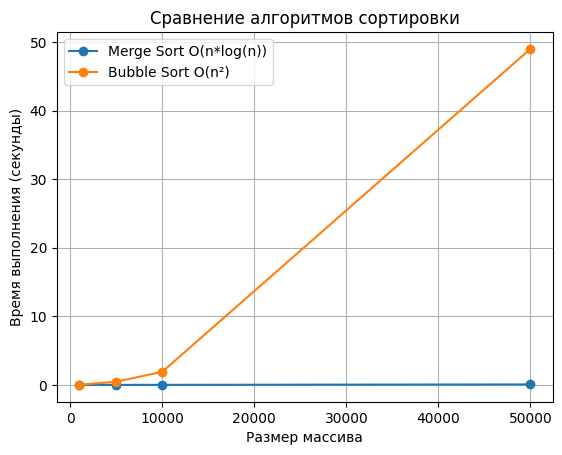

In [8]:
# тест хаотичного, рандомизированного списка
sizes = [1000, 5 * 1000, 10000, 5 * 10000]
times_bubble = []
times_merge = []

for size in sizes:
    test_list = random_list_gen(size)

    time_bubble_count = 0

    time_merge_count = 0

    repeats = 10 if size < 50000 else 5

    for _ in range(repeats):
        merge_list = test_list.copy()
        bubble_list = test_list.copy()

        start = time.time()
        bubble_sort(bubble_list)
        end = time.time()
        time_bubble_count += end - start

        start = time.time()
        merge_sort(merge_list, 0, size - 1)
        end = time.time()
        time_merge_count += end - start
    times_bubble.append(time_bubble_count / repeats)
    times_merge.append(time_merge_count / repeats)

    print("test has been passed (fully rand)")

# построение графика
plt.plot(sizes, times_merge, marker='o', label='Merge Sort O(n*log(n))')
plt.plot(sizes, times_bubble, marker='o', label='Bubble Sort O(n²)')

plt.xlabel("Размер массива")
plt.ylabel("Время выполнения (секунды)")
plt.title("Сравнение алгоритмов сортировки")

plt.legend()
plt.grid(True)

plt.show()

In [9]:
times_merge

[0.0010324478149414062,
 0.005745887756347656,
 0.012363171577453614,
 0.07341876029968261]

In [10]:
times_bubble

[0.020870375633239745,
 0.47387170791625977,
 1.9128785610198975,
 48.97688131332397]

test has been passed (sorted)
test has been passed (sorted)
test has been passed (sorted)
test has been passed (sorted)


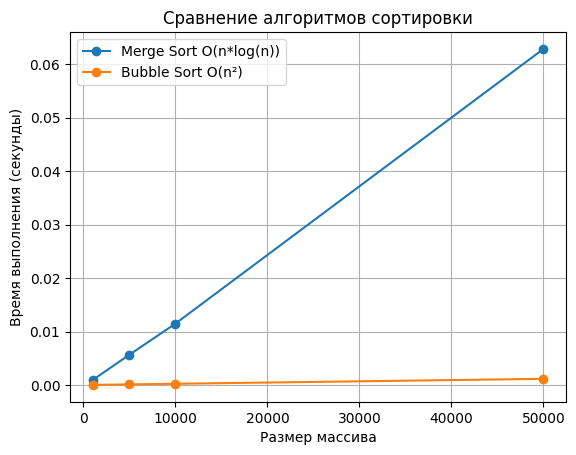

In [11]:
# тест отсортированного списка
sizes = [1000, 5 * 1000, 10000, 5 * 10000]
times_bubble = []
times_merge = []

for size in sizes:
    test_list = sorted(random_list_gen(size))

    time_bubble_count = 0

    time_merge_count = 0

    repeats = 10 if size < 50000 else 5

    for _ in range(repeats):
        merge_list = test_list.copy()
        bubble_list = test_list.copy()

        start = time.time()
        bubble_sort(bubble_list)
        end = time.time()
        time_bubble_count += end - start

        start = time.time()
        merge_sort(merge_list, 0, size - 1)
        end = time.time()
        time_merge_count += end - start
    times_bubble.append(time_bubble_count / repeats)
    times_merge.append(time_merge_count / repeats)

    print("test has been passed (sorted)")

# построение графика
plt.plot(sizes, times_merge, marker='o', label='Merge Sort O(n*log(n))')
plt.plot(sizes, times_bubble, marker='o', label='Bubble Sort O(n²)')

plt.xlabel("Размер входных данных (n)")
plt.ylabel("Время выполнения (секунды)")
plt.title("Сравнение времени выполнения функций")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
times_merge

[0.0009335041046142578,
 0.005670404434204102,
 0.011485433578491211,
 0.06287293434143067]

In [13]:
times_bubble

[2.1791458129882814e-05,
 0.00012216567993164062,
 0.00023455619812011718,
 0.001161813735961914]

test has been passed (almost sorted)
test has been passed (almost sorted)
test has been passed (almost sorted)
test has been passed (almost sorted)


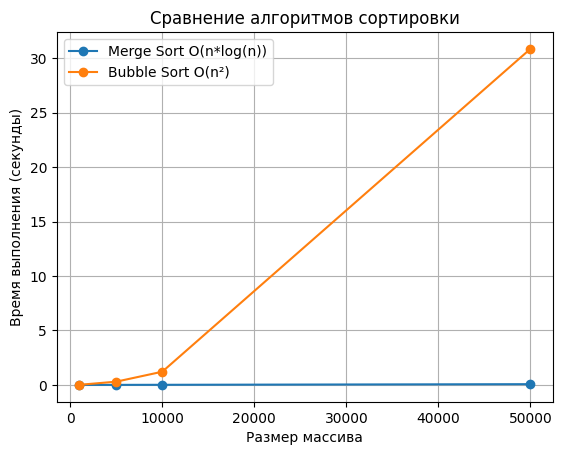

In [14]:
# тест почти отсортированного списка
sizes = [1000, 5 * 1000, 10000, 5 * 10000]
times_bubble = []
times_merge = []

for size in sizes:
    test_list = almost_sorted_list(size)

    time_bubble_count = 0

    time_merge_count = 0

    repeats = 10 if size < 50000 else 5

    for _ in range(repeats):
        merge_list = test_list.copy()
        bubble_list = test_list.copy()

        start = time.time()
        bubble_sort(bubble_list)
        end = time.time()
        time_bubble_count += end - start

        start = time.time()
        merge_sort(merge_list, 0, size - 1)
        end = time.time()
        time_merge_count += end - start
    times_bubble.append(time_bubble_count / repeats)
    times_merge.append(time_merge_count / repeats)

    print("test has been passed (almost sorted)")

# построение графика
plt.plot(sizes, times_merge, marker='o', label='Merge Sort O(n*log(n))')
plt.plot(sizes, times_bubble, marker='o', label='Bubble Sort O(n²)')

plt.xlabel("Размер массива")
plt.ylabel("Время выполнения (секунды)")
plt.title("Сравнение алгоритмов сортировки")

plt.legend()
plt.grid(True)

plt.show()

In [15]:
times_merge

[0.000953054428100586,
 0.0055648088455200195,
 0.012054204940795898,
 0.07029023170471191]

In [16]:
times_bubble

[0.011909985542297363,
 0.30029113292694093,
 1.213681411743164,
 30.86057596206665]

test has been passed (reversed)
test has been passed (reversed)
test has been passed (reversed)
test has been passed (reversed)


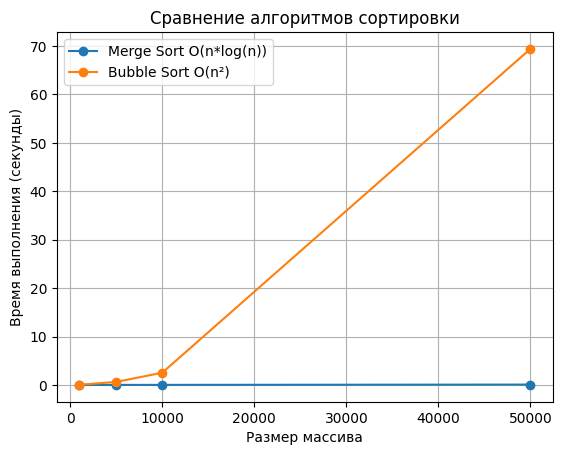

In [17]:
# тест обратного списка
sizes = [1000, 5 * 1000, 10000, 5 * 10000]
times_bubble = []
times_merge = []

for size in sizes:
    test_list = sorted(random_list_gen(size), reverse=True)

    time_bubble_count = 0

    time_merge_count = 0

    repeats = 10 if size < 50000 else 5

    for _ in range(repeats):
        merge_list = test_list.copy()
        bubble_list = test_list.copy()

        start = time.time()
        bubble_sort(bubble_list)
        end = time.time()
        time_bubble_count += end - start

        start = time.time()
        merge_sort(merge_list, 0, size - 1)
        end = time.time()
        time_merge_count += end - start
    times_bubble.append(time_bubble_count / repeats)
    times_merge.append(time_merge_count / repeats)

    print("test has been passed (reversed)")

# построение графика
plt.plot(sizes, times_merge, marker='o', label='Merge Sort O(n*log(n))')
plt.plot(sizes, times_bubble, marker='o', label='Bubble Sort O(n²)')

plt.xlabel("Размер массива")
plt.ylabel("Время выполнения (секунды)")
plt.title("Сравнение алгоритмов сортировки")

plt.legend()
plt.grid(True)

plt.show()

In [18]:
times_merge

[0.0009580850601196289,
 0.005190706253051758,
 0.011131095886230468,
 0.07301397323608398]

In [19]:
times_bubble

[0.02641892433166504, 0.6233097314834595, 2.5248697280883787, 69.3994529724121]